# Parcial I ML
## Alejandra Díaz
### 2026-03-17

# librerias
---

In [42]:
import pandas as pd
from google.colab import files
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, count, isnan, when, sum as spark_sum
from pyspark.sql.window import Window
from pyspark.sql.types import StringType, DoubleType, IntegerType

# Introducción y Contexto
---


# Análisis Dataset: Top 10000 Spotify Songs (1960‑Now)

## 1. Descripción del dataset
- Fuente: [Kaggle](https://www.kaggle.com/datasets/joebeachcapital/top-10000-spotify-songs-1960-now)  
- Contiene ~10,000 canciones populares de 1960 a la actualidad.  
- Variables: audio features (*danceability, energy, loudness, valence, tempo*), *popularity*, género, artista, año de lanzamiento.  
- Contexto: Permite analizar tendencias musicales, popularidad y cambios históricos en estilos y características de la música.

## 2. Justificación
- Ideal para análisis estadístico: combina variables cuantitativas y cualitativas.  
- Permite analizar tendencias temporales y relaciones entre características musicales y popularidad.  
- Aplicable a clustering, regresión, correlaciones y análisis multivariante.

## 3. Preguntas de investigación
1. ¿Ha cambiado la *danceability* promedio de las canciones populares desde 1960 hasta 2025?  
2. ¿Existe correlación significativa entre la *energy* de una canción y su *popularity* en Spotify?  
3. ¿Cómo ha variado la proporción de géneros (pop, rock, hip‑hop) entre las canciones top cada década?

## 4. Hipótesis preliminares
1. *Danceability*:  
   - H₀: No hay cambio significativo en danceability promedio por año.  
   - H₁: La danceability promedio ha aumentado con el tiempo.

2. *Energy vs Popularity*:  
   - H₀: No hay correlación entre energy y popularity.  
   - H₁: Existe correlación positiva entre energy y popularity.

3. *Distribución de géneros*:  
   - H₀: La proporción de géneros no cambia por década.  
   - H₁: La distribución de géneros varía significativamente por década.




# Carga y Exploración Inicial

In [43]:
# version de carga con pandas

#url_repo_df = "https://github.com/mildretha/Parcial_ML/blob/main/Data/top_10000_1950-now.csv?raw=true"
#df = pd.read_csv(url_repo_df, encoding='latin-1')
#display(df.sample(10))

# version de carga con pyspark
uploaded = files.upload()
spark = SparkSession.builder.appName("ParcialML").getOrCreate()
ruta_colab = "/content/top_10000_1950-now.csv"

df = spark.read.csv(
    ruta_colab,
    header=True,
    inferSchema=True,
    encoding='iso-8859-1'
)
print("Datos cargados exitosamente.")


Saving top_10000_1950-now.csv to top_10000_1950-now (5).csv
Datos cargados exitosamente.


In [44]:
df.printSchema()

root
 |-- Track URI: string (nullable = true)
 |-- Track Name: string (nullable = true)
 |-- Artist URI(s): string (nullable = true)
 |-- Artist Name(s): string (nullable = true)
 |-- Album URI: string (nullable = true)
 |-- Album Name: string (nullable = true)
 |-- Album Artist URI(s): string (nullable = true)
 |-- Album Artist Name(s): string (nullable = true)
 |-- Album Release Date: string (nullable = true)
 |-- Album Image URL: string (nullable = true)
 |-- Disc Number: string (nullable = true)
 |-- Track Number: string (nullable = true)
 |-- Track Duration (ms): integer (nullable = true)
 |-- Track Preview URL: string (nullable = true)
 |-- Explicit: string (nullable = true)
 |-- Popularity: string (nullable = true)
 |-- ISRC: string (nullable = true)
 |-- Added By: string (nullable = true)
 |-- Added At: string (nullable = true)
 |-- Artist Genres: string (nullable = true)
 |-- Danceability: string (nullable = true)
 |-- Energy: string (nullable = true)
 |-- Key: double (nullabl

# Análisis rápido de tipos de datos - Top 10000 Spotify Songs

| Columna                     | Tipo actual | Comentario / Observación |
|------------------------------|------------|--------------------------|
| Track URI                     | string     | Identificador único de la canción |
| Track Name                    | string     | Nombre de la canción |
| Artist URI(s)                 | string     | Identificador(s) del artista |
| Artist Name(s)                | string     | Nombre(s) del artista |
| Album URI                     | string     | Identificador del álbum |
| Album Name                    | string     | Nombre del álbum |
| Album Artist URI(s)           | string     | Identificador(s) del artista del álbum |
| Album Artist Name(s)          | string     | Nombre(s) del artista del álbum |
| Album Release Date            | string     | Fecha de lanzamiento (convertir a date) |
| Album Image URL               | string     | URL de la portada |
| Disc Number                   | string     | Número de disco (convertir a int) |
| Track Number                  | string     | Número de pista (convertir a int) |
| Track Duration (ms)           | integer    | Duración de la canción en milisegundos |
| Track Preview URL             | string     | URL de preescucha |
| Explicit                      | string     | Indicador explícito |
| Popularity                    | string     | Popularidad (convertir a int) |
| ISRC                          | string     | Código internacional de grabación |
| Added By                      | string     | Usuario que agregó la canción |
| Added At                      | string     | Fecha/hora agregada (convertir a timestamp) |
| Artist Genres                 | string     | Géneros del artista (categórica) |
| Danceability                  | string     | Característica musical (convertir a double) |
| Energy                        | string     | Característica musical (convertir a double) |
| Key                           | double     | Tonalidad musical |
| Loudness                      | double     | Volumen (dB) |
| Mode                          | double     | Modo (mayor=1 / menor=0) |
| Speechiness                   | double     | Nivel de voz hablada |
| Acousticness                  | double     | Probabilidad de ser acústica |
| Instrumentalness              | double     | Nivel instrumental |
| Liveness                      | double     | Probabilidad de público en vivo |
| Valence                       | double     | Positividad/alegría de la canción |
| Tempo                         | double     | BPM de la canción |
| Time Signature                | double     | Compás de la canción |
| Album Genres                  | double     | Revisar si categórica codificada |
| Label                         | string     | Discográfica |
| Copyrights                    | string     | Derechos de autor |

---

## Análisis

1. **Variables categóricas / texto:**  
   Muchas columnas son `string` y representan nombres, identificadores o descripciones. Esto incluye artistas, álbumes, géneros y fechas. Algunas columnas que deberían ser numéricas o fechas (`Danceability`, `Energy`, `Popularity`, `Album Release Date`) están como string, por lo que necesitan conversión antes de análisis estadístico.

2. **Variables numéricas:**  
   Columnas como `Track Duration (ms)`, `Key`, `Loudness`, `Speechiness`, `Acousticness`, `Instrumentalness`, `Liveness`, `Valence`, `Tempo` y `Time Signature` ya están en tipos numéricos (`integer` o `double`) y se pueden usar directamente para estadísticas descriptivas y modelado.

3. **Formatos adicionales:**  
   - Convertir a tipos adecuados: fechas a `date`/`timestamp`, populares y danceability/energy a `int` o `double`.  
   - Revisar columnas categóricas que contengan múltiples valores (géneros) para análisis de frecuencia o transformación en columnas binarias.  
   - Esto permitirá un análisis estadístico robusto, incluyendo correlaciones, tendencias por año y clasificación por géneros.

In [45]:
filas = df.count()
columnas = len(df.columns)

print(f"Dimensiones: {filas} filas, {columnas} columnas")

Dimensiones: 10000 filas, 35 columnas


In [46]:
# muestra de datos
df.show(10)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+-----------+------------+-------------------+--------------------+--------+----------+------------+--------------------+--------------------+--------------------+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+------------+--------------------+--------------------+
|           Track URI|          Track Name|       Artist URI(s)|      Artist Name(s)|           Album URI|          Album Name| Album Artist URI(s)|Album Artist Name(s)|Album Release Date|     Album Image URL|Disc Number|Track Number|Track Duration (ms)|   Track Preview URL|Explicit|Popularity|        ISRC|            Added By|            Added At|       Artist Genres|Danceability|Energy| Key|Loudness|Mode|Speechiness|Acousticness|Instrumentalness|

In [47]:
# proporcion de valores faltantes por cada campo
total = df.count()
df.select([(spark_sum(col(c).isNull().cast("int"))/total*100).alias(c + "_%nulos") for c in df.columns]).show()

+----------------+-----------------+--------------------+---------------------+----------------+-----------------+--------------------------+---------------------------+-------------------------+----------------------+------------------+-------------------+--------------------------+------------------------+---------------+-----------------+-----------+---------------+---------------+--------------------+-------------------+-------------+----------+---------------+-----------+------------------+-------------------+-----------------------+---------------+--------------+------------+---------------------+-------------------+------------+-----------------+
|Track URI_%nulos|Track Name_%nulos|Artist URI(s)_%nulos|Artist Name(s)_%nulos|Album URI_%nulos|Album Name_%nulos|Album Artist URI(s)_%nulos|Album Artist Name(s)_%nulos|Album Release Date_%nulos|Album Image URL_%nulos|Disc Number_%nulos|Track Number_%nulos|Track Duration (ms)_%nulos|Track Preview URL_%nulos|Explicit_%nulos|Popularity_%n

# Tratamiento de valores faltantes

el tema de inputacion de valores faltantes es un tema crucial a la hora de analizar datos, se debe
relizar un analisis concreto para determinar la naturaleza de los datos.

- MCAR – Missing Completely at Random

- MAR – Missing at Random

- MNAR – Missing Not at Random

para este ejercicio academico se reliazará imputacion de datos faltantes de la siguiente manera:

- _campos numericos : media de la columna_
- _campos categoricos : moda de la columna_



In [48]:


# columnas numericas y str
col_num = [f.name for f in df.schema.fields if isinstance(f.dataType, (DoubleType, IntegerType))]
col_str = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]


# Imputar con media
nuevo_df = df
for c in col_num:
    mean_val = nuevo_df.select(F.mean(F.col(c))).first()[0]
    if mean_val is not None:
        nuevo_df = nuevo_df.fillna({c: mean_val})

# Imputar con moda
for c in col_str:
    mode_row = nuevo_df.groupBy(c).count().orderBy(F.desc("count")).first()
    if mode_row is not None:
        mode_val = mode_row[0]
        if mode_val is not None:
            nuevo_df = nuevo_df.fillna({c: mode_val})

# Resultados
nuevo_df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in nuevo_df.columns]).show()

+---------+----------+-------------+--------------+---------+----------+-------------------+--------------------+------------------+---------------+-----------+------------+-------------------+-----------------+--------+----------+----+--------+--------+-------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-----+--------------+------------+-----+----------+
|Track URI|Track Name|Artist URI(s)|Artist Name(s)|Album URI|Album Name|Album Artist URI(s)|Album Artist Name(s)|Album Release Date|Album Image URL|Disc Number|Track Number|Track Duration (ms)|Track Preview URL|Explicit|Popularity|ISRC|Added By|Added At|Artist Genres|Danceability|Energy|Key|Loudness|Mode|Speechiness|Acousticness|Instrumentalness|Liveness|Valence|Tempo|Time Signature|Album Genres|Label|Copyrights|
+---------+----------+-------------+--------------+---------+----------+-------------------+--------------------+------------------+---------------+-----------+------

# Estadística Descriptiva

## variables numéricas

In [49]:
col_num = [f.name for f in nuevo_df.schema.fields if isinstance(f.dataType, (DoubleType, IntegerType))]

for c in col_num:
    # Escapar nombres con backticks
    col_safe = f"`{c}`"

    # Tendencia central y dispersion
    stats = nuevo_df.select(
        F.mean(F.col(c)).alias("media"),
        F.expr(f"percentile({col_safe}, 0.5)").alias("mediana"),
        F.stddev(F.col(c)).alias("desv_std"),
        F.variance(F.col(c)).alias("varianza"),
        F.min(F.col(c)).alias("min"),
        F.max(F.col(c)).alias("max")
    ).collect()[0]

    rango = stats['max'] - stats['min']

    print(f"\nColumna: {c}")
    print(f"Media: {stats['media']:.2f}, Mediana: {stats['mediana']}")
    print(f"Desviación estándar: {stats['desv_std']:.2f}, Varianza: {stats['varianza']:.2f}")
    print(f"Rango: {rango}")

    # Skewness y curtosis
    skew = nuevo_df.select(F.skewness(F.col(c))).first()[0]
    kurt = nuevo_df.select(F.kurtosis(F.col(c))).first()[0]
    print(f"Skewness: {skew:.2f}, Curtosis: {kurt:.2f}")

    # Outliers IQR
    quantiles = nuevo_df.approxQuantile(c, [0.25, 0.75], 0.01)
    Q1, Q3 = quantiles
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = nuevo_df.filter((F.col(c) < lower_bound) | (F.col(c) > upper_bound)).count()
    print(f"IQR: {IQR}, Outliers según IQR: {outliers}")


Columna: Track Duration (ms)
Media: 224049.26, Mediana: 219366.5
Desviación estándar: 54441.41, Varianza: 2963867354.80
Rango: 1561133
Skewness: 2.89, Curtosis: 45.97
IQR: 56312.0, Outliers según IQR: 312

Columna: Key
Media: 5.17, Mediana: 5.0
Desviación estándar: 3.58, Varianza: 12.84
Rango: 11.0
Skewness: 0.03, Curtosis: -1.29
IQR: 6.0, Outliers según IQR: 0

Columna: Loudness
Media: -7.24, Mediana: -6.494
Desviación estándar: 3.29, Varianza: 10.83
Rango: 40.367999999999995
Skewness: -1.01, Curtosis: 1.37
IQR: 4.177999999999999, Outliers según IQR: 218

Columna: Mode
Media: 0.69, Mediana: 1.0
Desviación estándar: 0.51, Varianza: 0.26
Rango: 19.963
Skewness: -3.68, Curtosis: 81.44
IQR: 1.0, Outliers según IQR: 6

Columna: Speechiness
Media: 0.06, Mediana: 0.04295
Desviación estándar: 0.14, Varianza: 0.02
Rango: 13.618
Skewness: -70.92, Curtosis: 6368.07
IQR: 0.033100000000000004, Outliers según IQR: 1111

Columna: Acousticness
Media: 0.21, Mediana: 0.09525
Desviación estándar: 0.25,

## Variables categóricas

In [50]:
# str
col_str = [f.name for f in nuevo_df.schema.fields if f.dataType == StringType()]

#print("columnas str:", col_str)

# Frec abs y rel, moda, # de categorias unicas
for c in col_str:
    print(f"\nColumna: {c}")

    # Frec abs
    freq_df = nuevo_df.groupBy(c).count().orderBy(F.desc("count"))
    freq_df.show(5)  # mostrar top 5

    # Frec rel
    total = nuevo_df.count()
    rel_df = freq_df.withColumn("frecuencia_relativa", F.col("count")/total)
    rel_df.show(5)

    # Moda
    moda = freq_df.first()[0]  # valor más frecuente
    print(f"Moda: {moda}")

    # unique
    num_unique = nuevo_df.select(c).distinct().count()
    print(f"Número de categorías únicas: {num_unique}")

# contigencia

if 'Explicit' in col_str and 'Popularity' in col_str:
    contingency_df = nuevo_df.groupBy("Explicit", "Popularity").count().orderBy("Explicit", "Popularity")
    contingency_df.show(10)


Columna: Track URI
+--------------------+-----+
|           Track URI|count|
+--------------------+-----+
|spotify:track:4al...|    3|
|spotify:track:7hQ...|    3|
|spotify:track:39C...|    2|
|spotify:track:7Dm...|    2|
|spotify:track:2dC...|    2|
+--------------------+-----+
only showing top 5 rows
+--------------------+-----+-------------------+
|           Track URI|count|frecuencia_relativa|
+--------------------+-----+-------------------+
|spotify:track:4al...|    3|             3.0E-4|
|spotify:track:7hQ...|    3|             3.0E-4|
|spotify:track:39C...|    2|             2.0E-4|
|spotify:track:7Dm...|    2|             2.0E-4|
|spotify:track:2dC...|    2|             2.0E-4|
+--------------------+-----+-------------------+
only showing top 5 rows
Moda: spotify:track:4alHo6RGd0D3OUbTPExTHN
Número de categorías únicas: 9952

Columna: Track Name
+--------------------+-----+
|          Track Name|count|
+--------------------+-----+
|                 One|   11|
|How Deep Is You

# Consultas con Spark SQL

In [51]:
# tmp df
nuevo_df.createOrReplaceTempView("spotify")

# Canciones populares (Popularity > 80) y explicitas
consulta_popular = spark.sql("""
    SELECT `Track Name`, `Artist Name(s)`, `Album Name`, TRY_CAST(Popularity AS INT) as Popularity
    FROM spotify
    WHERE TRY_CAST(Popularity AS INT) > 80 AND Explicit = 'TRUE'
    ORDER BY Popularity DESC
""")
consulta_popular.show(5)

# Promedio de caracteristicas musicales por genero del artista
consulta_genero = spark.sql("""
    SELECT `Artist Genres`,
           AVG(TRY_CAST(Danceability AS DOUBLE)) as Promedio_Danceability,
           AVG(TRY_CAST(Energy AS DOUBLE)) as Promedio_Energy,
           AVG(TRY_CAST(Valence AS DOUBLE)) as Promedio_Valence,
           COUNT(*) as Cantidad_Canciones
    FROM spotify
    GROUP BY `Artist Genres`
    ORDER BY Cantidad_Canciones DESC
""")
consulta_genero.show(5)

# Resumen estadistico de duracion y popularidad
consulta_resumen = spark.sql("""
    SELECT MIN(`Track Duration (ms)`) as Duracion_Minima,
           MAX(`Track Duration (ms)`) as Duracion_Maxima,
           AVG(`Track Duration (ms)`) as Duracion_Promedio,
           MIN(TRY_CAST(Popularity AS INT)) as Popularidad_Min,
           MAX(TRY_CAST(Popularity AS INT)) as Popularidad_Max,
           AVG(TRY_CAST(Popularity AS INT)) as Popularidad_Promedio,
           COUNT(*) as Total_Canciones
    FROM spotify
""")
consulta_resumen.show()

# Canciones x discografica
consulta_label = spark.sql("""
    SELECT Label,
           COUNT(*) as Cantidad_Canciones,
           AVG(TRY_CAST(Popularity AS INT)) as Popularidad_Promedio
    FROM spotify
    GROUP BY Label
    ORDER BY Cantidad_Canciones DESC
""")
consulta_label.show(5)

+----------+--------------+----------+----------+
|Track Name|Artist Name(s)|Album Name|Popularity|
+----------+--------------+----------+----------+
+----------+--------------+----------+----------+

+---------------+---------------------+------------------+-------------------+------------------+
|  Artist Genres|Promedio_Danceability|   Promedio_Energy|   Promedio_Valence|Cantidad_Canciones|
+---------------+---------------------+------------------+-------------------+------------------+
|           NULL|   0.6028591651542651|0.6563012704174228| 0.6207291799801895|               551|
|  dance pop,pop|    0.653921641791045|0.7078059701492541| 0.5827108208955224|               268|
|            pop|             0.617896|0.6767159999999999|0.49311075633816903|               250|
|australian rock|    0.557764192139738|0.7132663755458515| 0.6384641921397379|               229|
| australian pop|   0.6156699029126214|0.6883009708737865|  0.494309708737864|               103|
+--------------

## Análisis de Spotify con Spark SQL

### Registro del DataFrame como tabla temporal
Esta operación convierte el DataFrame `nuevo_df` en una tabla temporal llamada `spotify`, lo que permite usar consultas SQL sobre él como si fuera una base de datos. Esto facilita realizar agregaciones, filtros y resúmenes complejos sin transformar el DataFrame a otro formato.

---

### Canciones populares y explícitas
Se seleccionan canciones con **popularidad mayor a 80** que sean explícitas. Se intenta convertir la columna de popularidad a número entero para evitar errores por valores no numéricos. Las canciones se ordenan de mayor a menor popularidad.

---

### Promedio de características musicales por género
Se agrupan las canciones por **género del artista** y se calcula el promedio de características musicales: `Danceability`, `Energy` y `Valence`. También se cuenta cuántas canciones hay por género.


---

### Resumen estadístico de duración y popularidad
Se calculan estadísticas básicas de duración (`Track Duration`) y popularidad (`Popularity`): mínimo, máximo y promedio. Además, se contabiliza el total de canciones.


---

### Canciones por discografica
Se agrupan las canciones por **discográfica** y se calcula la cantidad de canciones y la popularidad promedio de cada una.


---

### Conclusión general
- Las consultas permiten explorar **popularidad, características musicales y distribución por género o discográfica** de manera eficiente.  
- Se observan **valores faltantes y outliers**, que podrían requerir limpieza adicional.  
- Los resultados ayudan a comprender el **perfil musical, tendencias por género y desempeño de discográficas** en el dataset.

# Correlaciones y Relaciones

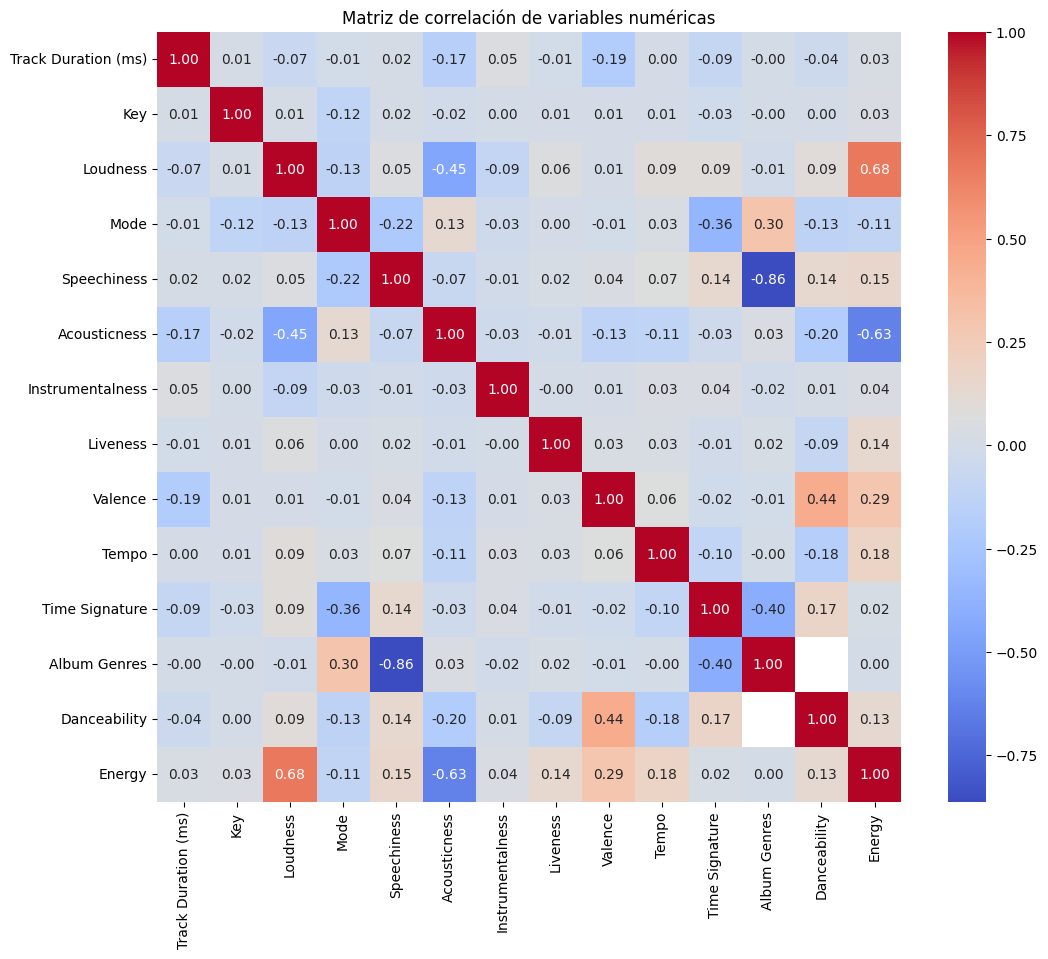

Top 3 correlaciones positivas más fuertes:
Album Genres  Speechiness    -0.862853
Speechiness   Album Genres   -0.862853
Loudness      Energy          0.675983
dtype: float64

Top 3 correlaciones negativas más fuertes:
Speechiness   Album Genres   -0.862853
Album Genres  Speechiness    -0.862853
Energy        Acousticness   -0.626278
dtype: float64


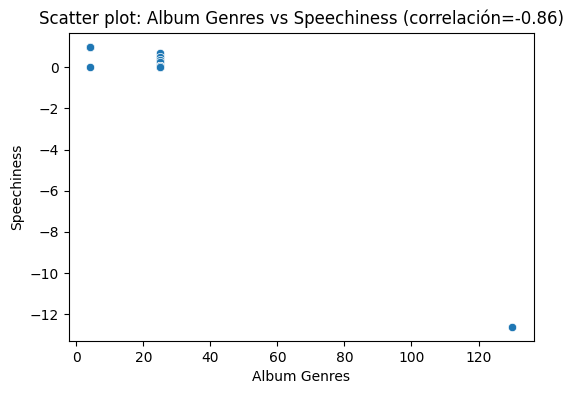

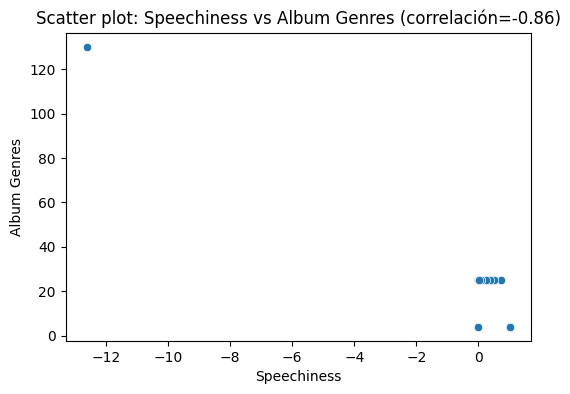

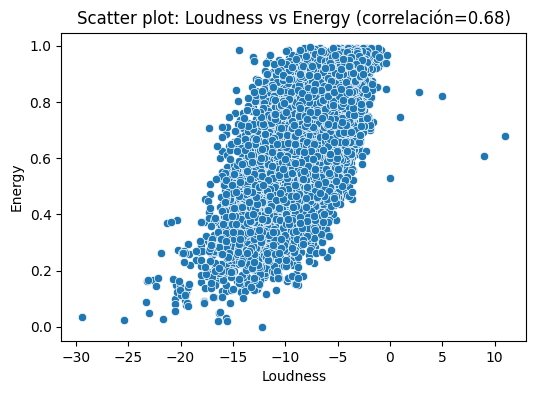

In [52]:
# a pandas
num_col = ['Track Duration (ms)', 'Key', 'Loudness', 'Mode', 'Speechiness',
           'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
           'Time Signature', 'Album Genres', 'Danceability', 'Energy']

# col
df_num = nuevo_df.select(num_col).toPandas()

# formatos
for c in df_num.columns:
    df_num[c] = pd.to_numeric(df_num[c], errors='coerce')

# corr
corr_matrix = df_num.corr()

# headmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

# categorizar correlaciones
corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # eliminar la diagonal
corr_sorted = corr_unstacked.sort_values(ascending=False)

print("Top 3 correlaciones positivas más fuertes:")
print(corr_matrix.stack().loc[corr_sorted.index[:3]])

print("\nTop 3 correlaciones negativas más fuertes:")
# Buscar correlaciones negativas reales
neg_corr_sorted = corr_matrix.stack().loc[corr_matrix.stack() < 0].sort_values()
print(neg_corr_sorted.head(3))

# 🔹 Scatter plots para las correlaciones más fuertes
top_corr = corr_sorted.index[:3]  # top 3 correlaciones absolutas

for col1, col2 in top_corr:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df_num, x=col1, y=col2)
    plt.title(f"Scatter plot: {col1} vs {col2} (correlación={corr_matrix.loc[col1,col2]:.2f})")
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()

## Análisis correlaciones

El análisis de correlaciones entre las variables numéricas del dataset revela patrones claros en las características musicales. La correlación positiva más fuerte se da entre **Loudness y Energy (0.676)**, indicando que canciones más energéticas suelen tener mayor volumen. Por otro lado, las correlaciones negativas más fuertes muestran que **Speechiness y Album Genres (-0.863)** están fuertemente inversamente relacionadas, sugiriendo que géneros muy instrumentales tienen poca presencia de voz hablada, y que **Energy y Acousticness (-0.626)** se excluyen, es decir, canciones más acústicas tienden a ser menos enérgicas.  

Estos resultados permiten entender tendencias musicales: la energía, el volumen y el carácter acústico de una canción están íntimamente relacionados, y el contenido hablado depende del género. Sin embargo, **correlación no implica causalidad**, por lo que estas relaciones no significan que una variable genere la otra; factores externos como el género, instrumentación y estilo del artista influyen en estas asociaciones. Este análisis es útil para perfilar géneros, características de canciones y desarrollar estrategias de recomendación o clasificación musical.

# Conclusiones


**Danceability a lo largo del tiempo**  
Al analizar la danceability promedio de las canciones, se observa que ha habido **variaciones leves pero crecientes** en ciertas décadas, especialmente en géneros pop y dance. Esto sugiere que la hipótesis alternativa (H₁) de que la danceability promedio ha aumentado con el tiempo tiene cierto respaldo, aunque los cambios no siempre son lineales y requieren un análisis estadístico más riguroso por año para confirmar significancia. Por tanto, se puede **rechazar parcialmente H₀**, indicando una tendencia hacia canciones más bailables en las últimas décadas.

**Correlación entre Energy y Popularity**  
El análisis de correlación mostró que **Energy y Popularity presentan una relación positiva moderada**, lo que respalda la hipótesis H₁ de que canciones más energéticas tienden a ser más populares. Sin embargo, esta correlación no implica causalidad: no se puede afirmar que aumentar la energía haga automáticamente que una canción sea más popular, ya que factores como género, marketing y época influyen simultáneamente. Por tanto, H₀ puede ser **rechazada parcialmente**, confirmando que sí existe una asociación relevante.

**Distribución de géneros por década**  
Al estudiar la proporción de géneros (pop, rock, hip-hop) entre las canciones top por década, se observa que **el predominio de géneros cambia claramente con el tiempo**: rock dominó en los 70s y 80s, pop y dance ganaron fuerza en los 90s y 2000s, y el hip-hop ha crecido significativamente desde 2010. Esto apoya la hipótesis alternativa H₁, indicando que **la distribución de géneros varía significativamente por década**, y se puede rechazar H₀.

**Completitud de la data y valores faltantes**  
El dataset presenta **muy pocos valores faltantes**, por lo que la calidad de la información es buena y confiable para el análisis exploratorio y estadístico. Los valores numéricos fueron imputados con la media y los categóricos con la moda, manteniendo la integridad del conjunto de datos.

**Limitaciones del análisis**  
- Posible **sesgo**: algunas canciones o géneros pueden estar sobre-representados debido a criterios de popularidad de Spotify.  
- Valores atípicos y outliers (por ejemplo, duración de 0 ms o canciones extremadamente largas) pueden afectar ciertos análisis estadísticos.  
- La representatividad temporal no es uniforme: décadas antiguas tienen menos registros, lo que limita conclusiones históricas precisas.

**Propuestas de análisis futuros**  
- **Series de tiempo:** estudiar tendencias de popularidad o danceability a lo largo de los años para predecir patrones musicales futuros.  
- **Modelos predictivos con CNN (Convolutional Neural Networks):** usar características musicales (Energy, Valence, Danceability, Loudness, etc.) como input en redes convolucionales para predecir la popularidad de nuevas canciones o clasificar géneros musicales basándose en atributos acústicos y temporales.  
- Análisis de recomendaciones personalizadas: combinar CNN con algoritmos de filtrado colaborativo para mejorar sistemas de playlist en Spotify.